# BARDWS Driver Earnings Analysis
This notebook validates the data quality of the cleaned and enriched BARDWS dataset and analyzes day-of-week and monthly earnings patterns.

## Setup & Configuration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# Configure plots for modern aesthetic
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['grid.alpha'] = 0.5

# Color palette definitions (HSL Tailored)
PRIMARY_COLOR = '#3f51b5' # Sleek indigo
SECONDARY_COLOR = '#009688' # Teal
PALETTE = ['#4A90E2', '#5C6BC0', '#26A69A', '#66BB6A', '#FFCA28', '#FF7043', '#EC407A']

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load Dataset
We read the cleaned and enriched driver logs dataset generated by the pipeline.

In [2]:
# Locate latest dataset
csv_files = sorted(glob.glob('../02_datasets/bardws_dataset_driver-enriched_v1_*.csv'))
if not csv_files:
    # Check locally if running from workspace root
    csv_files = sorted(glob.glob('02_datasets/bardws_dataset_driver-enriched_v1_*.csv'))

latest_csv = csv_files[-1] if csv_files else 'bardws_dataset_driver-enriched_v1_2026-06-22.csv'
df = pd.read_csv(latest_csv)
print(f"Loaded dataset: {latest_csv}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Loaded dataset: ../02_datasets\bardws_dataset_driver-enriched_v1_2026-06-22.csv
Rows: 131373, Columns: 15


,driver_id,log_date,demand_zone,hours_worked,km_driven,rides_completed,gross_fare_inr,fuel_topped_up_litres,sick_day,hours_outlier,rainfall_mm,temp_max_c,temp_min_c,humidity_pct,retail_price_inr_per_litre
0,BARDWS-1000,2023-01-01,Wilson Garden,12.85,244.9,31,2616.85,0.0,0,0,0.0,24.5,14.9,59.0,85.39
1,BARDWS-1000,2023-01-02,Wilson Garden,9.78,104.2,16,869.89,0.0,0,0,0.0,25.5,14.5,53.0,85.51
2,BARDWS-1000,2023-01-03,Wilson Garden,6.81,72.6,14,1030.36,0.0,0,0,0.0,23.4,13.1,59.0,85.51
3,BARDWS-1000,2023-01-04,Wilson Garden,8.80,101.5,15,1103.60,0.0,0,0,0.0,25.3,13.5,45.0,85.47
4,BARDWS-1000,2023-01-05,Wilson Garden,0.00,0.0,0,0.00,0.0,1,0,0.0,24.2,12.4,45.0,85.44


## 2. Data Quality Validation
Let's confirm that our data tidying steps succeeded:
- Zero duplicate driver-day rows.
- Exactly 12 outlier rows (where hours_worked = 26) flagged.
- Zero missing values for `km_driven` and `gross_fare_inr` (due to successful imputation).

In [3]:
print("=== DATA QUALITY VALIDATION ===")
dupes = df.duplicated(subset=['driver_id', 'log_date']).sum()
print(f"Duplicate driver-day rows: {dupes} (Expected: 0)")

outliers = (df['hours_outlier'] == 1).sum()
print(f"Flagged outlier rows (hours_worked == 26): {outliers} (Expected: 12)")

missing_km = df['km_driven'].isnull().sum()
print(f"Missing values in km_driven: {missing_km} (Expected: 0)")

missing_fare = df['gross_fare_inr'].isnull().sum()
print(f"Missing values in gross_fare_inr: {missing_fare} (Expected: 0)")

=== DATA QUALITY VALIDATION ===
Duplicate driver-day rows: 0 (Expected: 0)
Flagged outlier rows (hours_worked == 26): 12 (Expected: 12)
Missing values in km_driven: 0 (Expected: 0)
Missing values in gross_fare_inr: 0 (Expected: 0)


## 3. Day-of-Week Earnings Analysis
We analyze driver earnings by day of the week to see when drivers make the most gross fare.

=== DAY-OF-WEEK GROSS FARE STATS (INR) ===
                mean   median
day_of_week                  
Monday       1551.77  1499.75
Tuesday      1537.29  1495.66
Wednesday    1530.65  1479.34
Thursday     1548.93  1497.85
Friday       1545.79  1496.74
Saturday     1544.63  1497.57
Sunday       1539.11  1490.79


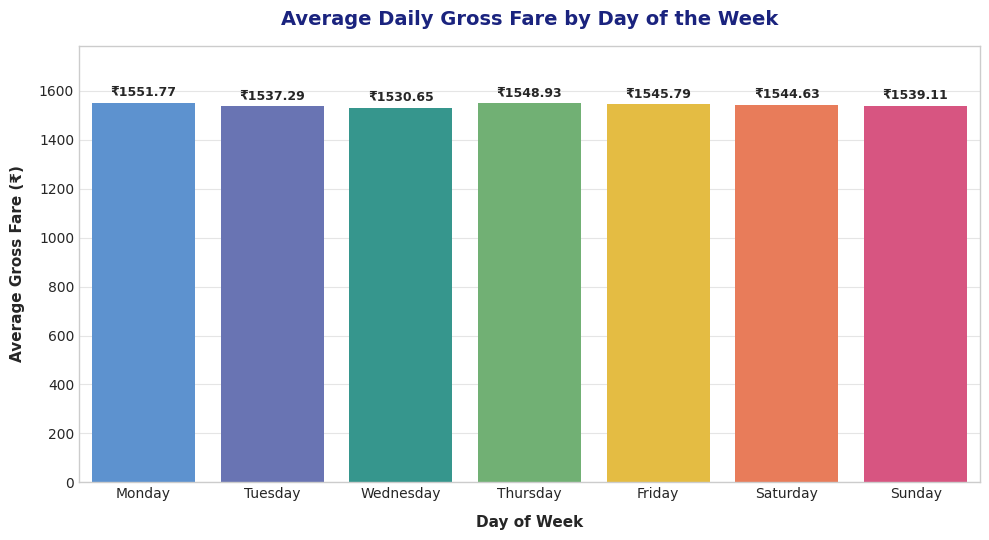

In [4]:
# Convert log_date to datetime and extract Day of Week
df['log_date'] = pd.to_datetime(df['log_date'])
df['day_of_week'] = df['log_date'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_stats = df.groupby('day_of_week')['gross_fare_inr'].agg(['mean', 'median']).reindex(day_order)

print("=== DAY-OF-WEEK GROSS FARE STATS (INR) ===")
print(dow_stats.round(2))

# Plotting with beautiful aesthetics
plt.figure(figsize=(10, 5.5))
sns.barplot(x=dow_stats.index, y=dow_stats['mean'], palette=PALETTE, hue=dow_stats.index, legend=False)
plt.title('Average Daily Gross Fare by Day of the Week', pad=15, fontweight='bold', color='#1A237E')
plt.xlabel('Day of Week', labelpad=10, fontweight='bold')
plt.ylabel('Average Gross Fare (₹)', labelpad=10, fontweight='bold')
plt.ylim(0, dow_stats['mean'].max() * 1.15)

# Add values on top of bars
for i, val in enumerate(dow_stats['mean']):
    plt.text(i, val + 15, f"₹{val:.2f}", ha='center', va='bottom', fontsize=9, fontweight='semibold')

plt.tight_layout()
plt.savefig('day_of_week_earnings.png', dpi=300)
plt.show()

## 4. Monthly Earnings Analysis
We aggregate daily fares to monthly totals for each driver to study month-over-month earnings trends across the 24-month window (2023 - 2024).

=== MONTHLY DRIVER EARNINGS (INR) ===
                mean    median
year_month                    
2023-01     38931.05  38749.37
2023-02     35698.80  35452.07
2023-03     39645.05  39494.22
2023-04     38313.11  37733.94
2023-05     38986.21  38365.87
2023-06     37348.72  36963.65
2023-07     38586.92  38407.98
2023-08     39501.67  38969.51
2023-09     37990.97  37953.51
2023-10     38922.19  39010.56
2023-11     39148.14  38234.11
2023-12     39148.63  39728.96
2024-01     43847.68  43691.84
2024-02     44114.39  43745.44
2024-03     47532.32  47981.87
2024-04     45868.10  44882.98
2024-05     47039.58  46837.98
2024-06     45047.87  43863.41
2024-07     45918.92  44945.06
2024-08     46144.33  46051.54
2024-09     46034.27  45169.22
2024-10     46845.57  47178.77
2024-11     45696.46  44486.33
2024-12     46968.22  47554.78


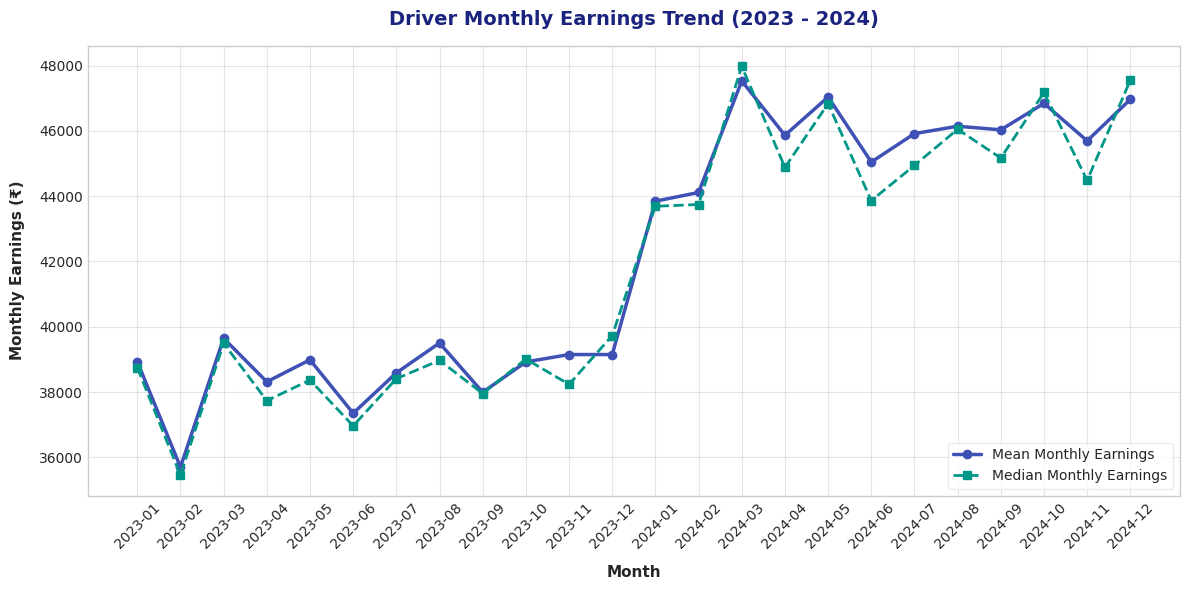

In [5]:
# Create year-month period
df['year_month'] = df['log_date'].dt.to_period('M')

# Calculate monthly earnings per driver
monthly_driver_fare = df.groupby(['driver_id', 'year_month'])['gross_fare_inr'].sum().reset_index()
monthly_stats = monthly_driver_fare.groupby('year_month')['gross_fare_inr'].agg(['mean', 'median'])

print("=== MONTHLY DRIVER EARNINGS (INR) ===")
print(monthly_stats.round(2))

# Plotting monthly earnings trend
plt.figure(figsize=(12, 6))
plt.plot(monthly_stats.index.astype(str), monthly_stats['mean'], marker='o', linewidth=2.5, color=PRIMARY_COLOR, label='Mean Monthly Earnings')
plt.plot(monthly_stats.index.astype(str), monthly_stats['median'], marker='s', linewidth=2, linestyle='--', color=SECONDARY_COLOR, label='Median Monthly Earnings')

plt.title('Driver Monthly Earnings Trend (2023 - 2024)', pad=15, fontweight='bold', color='#1A237E')
plt.xlabel('Month', labelpad=10, fontweight='bold')
plt.ylabel('Monthly Earnings (₹)', labelpad=10, fontweight='bold')
plt.xticks(rotation=45)
plt.legend(frameon=True, facecolor='white', edgecolor='#E2E8F0', loc='lower right')
plt.tight_layout()
plt.savefig('monthly_earnings_trend.png', dpi=300)
plt.show()